In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
from itertools import combinations
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller

# Cointegration and Correlation Analysis

In [18]:
# Function to fetch stock data using yfinance
def fetch_stock_data(ticker, start_date, end_date):
    stock_data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    # return (stock_data['Close'].pct_change().dropna() + 1).cumprod() - 1
    return stock_data['Close']


tickers = {
    # semi-conductor
    '688521.SS': 1,
    "603986.SS": 100,
    # beer
    "1876.HK": 100,
    "0291.HK": 500,
    # home electronics
    "0669.HK": 500,
    "6690.HK": 200,
}

pairs = ["semi-conductor", "beer", "home electronics"]

# z_score lookback window for each pair
windows = [12, 8, 6]

# Define entry and exit thresholds for the z_scores
entry_thresholds = [0.2, 1.8, 1.55]
exit_thresholds = [0.15, 0.7, 0.5]

In [21]:
start_date = "2020-07-01"
end_date = "2026-02-28"

[*********************100%***********************]  6 of 6 completed


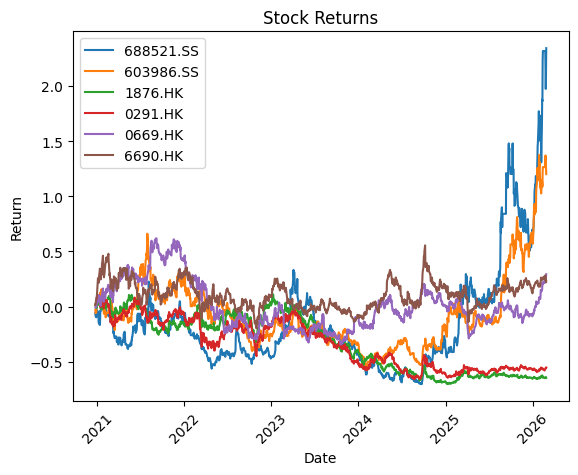

In [22]:
# Pairwise cointegration, correlation, and ADF spread test for all selected tickers

results = []

# Fetch price data for all tickers
price_data = fetch_stock_data(list(tickers.keys()), start_date, end_date)
price_data = price_data.ffill().dropna()
returns = (price_data.pct_change().dropna() + 1).cumprod() - 1

# Use the same series type as before (cumulative returns) for comparison
series = returns

for stock in tickers:
    paired_stock_data = returns[stock]
    # plt.plot(paired_stock_data, label=name_mapping[stock])
    plt.plot(paired_stock_data, label=stock)

plt.title('Stock Returns')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Return')
plt.legend()
plt.show()

# Backtest the Strategy

In [23]:
tick_list = list(tickers.keys())
left = price_data[tick_list[::2]].set_axis(pairs, axis=1)
right = price_data[tick_list[1::2]].set_axis(pairs, axis=1)
spreads = left - right

In [24]:
# Helper functions for backtesting

def generate_signals(z_scores, entry_thresholds, pairs):
    signals = pd.DataFrame(index=z_scores.index)
    for i in range(len(pairs)):
        signals[pairs[i]] = np.where(
            z_scores[pairs[i]] > entry_thresholds[i], -1, 
            np.where(z_scores[pairs[i]] < -entry_thresholds[i], 1, 0)
        )
    return signals

def calculate_daily_pnl(active_positions, price_data, tickers, pairs, i, borrowing_pct_cost_annual, short_sell_pct_cost_annual):
    daily_pnl = 0
    for pair_name in list(active_positions.keys()):
        pair_idx = pairs.index(pair_name)
        stock1_ticker = list(tickers.keys())[pair_idx * 2]
        stock2_ticker = list(tickers.keys())[pair_idx * 2 + 1]
        
        stock1_data = price_data[stock1_ticker]
        stock2_data = price_data[stock2_ticker]
        pos_info = active_positions[pair_name]
        position = pos_info['position']
        a = pos_info['a']
        b = pos_info['b']
        
        # Daily P&L
        if position == 1:  # Long
            r = (a * (stock1_data.iloc[i] - stock1_data.iloc[i-1]) - 
                 b * (stock2_data.iloc[i] - stock2_data.iloc[i-1]))
        elif position == -1:  # Short
            r = (b * (stock2_data.iloc[i] - stock2_data.iloc[i-1]) - 
                 a * (stock1_data.iloc[i] - stock1_data.iloc[i-1]))
        else:
            r = 0
        
        pos_info['current_pnl'] = pos_info.get('current_pnl', 0) + r
        daily_pnl += r
        
        # Financing costs
        p1 = stock1_data.iloc[i]
        p2 = stock2_data.iloc[i]
        current_notional = abs(a * p1) + abs(b * p2)
        borrowed_cash = max(0.0, current_notional - pos_info['entry_capital'])
        
        daily_borrow_interest = borrowed_cash * (borrowing_pct_cost_annual / 252)
        notional_short = b * p2 if position == 1 else a * p1
        daily_short_fee = max(0, notional_short) * (short_sell_pct_cost_annual / 252)
        financing_cost = -(daily_borrow_interest + daily_short_fee)
        
        daily_pnl += financing_cost
    
    return daily_pnl

def check_exits(active_positions, price_data, tickers, pairs, z_scores, exit_thresholds, stop_loss_pct, maintenance_margin_pct, current_capital, i, completed_trades, margin_call_count, stop_loss_count):
    transaction_cost_today = 0
    for pair_name in list(active_positions.keys()):
        pair_idx = pairs.index(pair_name)
        stock1_ticker = list(tickers.keys())[pair_idx * 2]
        stock2_ticker = list(tickers.keys())[pair_idx * 2 + 1]
        
        stock1_data = price_data[stock1_ticker]
        stock2_data = price_data[stock2_ticker]
        z_score = z_scores[pair_name]
        exit_threshold = exit_thresholds[pair_idx]
        
        pos_info = active_positions[pair_name]
        a = pos_info['a']
        b = pos_info['b']
        current_pnl = pos_info.get('current_pnl', 0)
        
        exit_signal = False
        exit_reason = None
        
        # Check stop loss
        if current_pnl / pos_info['entry_capital'] <= -stop_loss_pct:
            exit_signal = True
            exit_reason = 'stop_loss'
            stop_loss_count += 1
        
        # Check exit threshold
        elif abs(z_score.iloc[i]) < exit_threshold:
            exit_signal = True
            exit_reason = 'z_score'
        
        # Check margin call
        p1 = stock1_data.iloc[i]
        p2 = stock2_data.iloc[i]
        pos_market_value = abs(a * p1) + abs(b * p2)
        if pos_market_value > 0:
            margin_ratio = current_capital / pos_market_value
            if margin_ratio < maintenance_margin_pct:
                exit_signal = True
                exit_reason = 'margin_call'
                margin_call_count += 1
        
        if exit_signal:
            # Close position
            capital_used = a * p1 + b * p2
            exit_cost = -capital_used * 0.1105 / 100 - 15
            
            completed_trades.append({
                'pair': pair_name,
                'entry_index': pos_info['entry_index'],
                'entry_date': stock1_data.index[pos_info['entry_index']],
                'exit_index': i,
                'exit_date': stock1_data.index[i],
                'position': pos_info['position'],
                'entry_capital': pos_info['entry_capital'],
                'pnl': current_pnl,
                'exit_cost': exit_cost,
                'exit_reason': exit_reason
            })
            
            current_capital += exit_cost
            transaction_cost_today += exit_cost
            del active_positions[pair_name]
    
    return current_capital, transaction_cost_today, completed_trades, margin_call_count, stop_loss_count

def check_entries(active_positions, signals, price_data, tickers, stock_lots, pairs, z_scores, leverage, current_capital, i, transaction_cost_today, entry_thresholds):
    entry_signals_today = {}
    for pair_name in pairs:
        if pair_name not in active_positions and signals[pair_name].iloc[i] != 0:
            entry_signals_today[pair_name] = signals[pair_name].iloc[i]
    
    if entry_signals_today:
        # Calculate available capital after accounting for existing positions
        used_capital = sum(pos['entry_capital'] for pos in active_positions.values())
        available_capital = current_capital - used_capital
        
        # Prioritize pairs by signal strength (highest absolute z-score first)
        prioritized_pairs = sorted(entry_signals_today.keys(), key=lambda p: (abs(z_scores[p].iloc[i])-entry_thresholds[pairs.index(p)]), reverse=True)
        
        for pair_name in prioritized_pairs:
            if available_capital <= 0:
                break  # No more capital to allocate
            
            signal_direction = entry_signals_today[pair_name]
            pair_idx = pairs.index(pair_name)
            stock1_ticker = list(tickers.keys())[pair_idx * 2]
            stock2_ticker = list(tickers.keys())[pair_idx * 2 + 1]
            stock1_lot = stock_lots[stock1_ticker]
            stock2_lot = stock_lots[stock2_ticker]
            
            stock1_data = price_data[stock1_ticker]
            stock2_data = price_data[stock2_ticker]
            
            p1 = stock1_data.iloc[i]
            p2 = stock2_data.iloc[i]
            
            # Determine contract ratio
            pr = (p1 * stock1_lot) / (p2 * stock2_lot) if p2 > 0 else np.inf
            if pr < 1:
                a = 1 / pr
                b = 1
            else:
                a = 1
                b = pr
            
            cost_per_unit = a * stock1_lot * p1 + b * stock2_lot * p2
            
            # Allocate capital: up to 50% of current capital, but not more than available
            max_capital_for_this_pair = min(current_capital * 0.5, available_capital)
            
            # Size based on allocated capital
            if cost_per_unit > 0:
                multiple = int((max_capital_for_this_pair * leverage) / cost_per_unit)
            else:
                multiple = 0
            
            a = int(a * multiple) * stock1_lot
            b = int(b * multiple) * stock2_lot
            
            capital_used = a * p1 + b * p2
            entry_cost = -capital_used * 0.1105 / 100 - 15
            
            # Record new position
            active_positions[pair_name] = {
                'position': signal_direction,
                'a': a,
                'b': b,
                'entry_capital': max_capital_for_this_pair,
                'entry_price1': p1,
                'entry_price2': p2,
                'entry_index': i,
                'current_pnl': 0
            }
            
            # Update available capital
            available_capital -= max_capital_for_this_pair
            current_capital += entry_cost
            transaction_cost_today += entry_cost
    
    return current_capital, transaction_cost_today

def compute_summary(completed_trades, pct_returns, initial_capital, current_capital, price_data, risk_free_rate_annual, plot_stock_return):
    print(f"Completed trades: {len(completed_trades)}")
    print(f"Total return: {(current_capital - initial_capital) / initial_capital:.2%}")
    if len(pct_returns) > 0:
        print(f"Annualized return: {((current_capital / initial_capital) ** (252 / len(pct_returns)) - 1) * 100:.2f}%")
    
    # Calculate cumulative returns
    cumulative_pct_returns = np.cumprod(1 + np.array(pct_returns)) - 1 if len(pct_returns) > 0 else np.array([])
    
    if plot_stock_return:
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        ax.plot(price_data.index[1:1+len(cumulative_pct_returns)], cumulative_pct_returns, label='Multi-Pair Strategy', linewidth=2)
        ax.set_title('Multi-Pair Trading Strategy Cumulative Returns')
        ax.set_xlabel('Date')
        ax.set_ylabel('Cumulative Returns')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # Sharpe ratio
    daily_ex_returns = np.array(pct_returns) - ((1 + risk_free_rate_annual) ** (1/252) - 1)
    mean_daily = np.nanmean(daily_ex_returns)
    std_daily = np.nanstd(daily_ex_returns)
    if std_daily > 0:
        sharpe_ratio = (mean_daily / std_daily) * np.sqrt(252)
    else:
        sharpe_ratio = np.nan
    print(f"Sharpe Ratio (annualized): {sharpe_ratio:.4f}")
    
    return daily_ex_returns

def backtest_strategy_multi_pair(z_scores, price_data, tickers, stock_lots, pairs, windows, leverage, maintenance_margin_pct, borrowing_pct_cost_annual, short_sell_pct_cost_annual, entry_thresholds, exit_thresholds, stop_loss_pct, initial_capital, risk_free_rate_annual, plot_stock_return=True):
    """
    Multi-pair backtesting with dynamic capital allocation.
    - When ONE pair signals: allocate all available capital to it
    - When MULTIPLE pairs signal simultaneously: prioritize by signal strength
    - Each pair trades independently until its exit signal
    """
    current_capital = initial_capital
    
    # Generate signals
    signals = generate_signals(z_scores, entry_thresholds, pairs)
    
    # Track active positions per pair: {pair_name: {position, a, b, entry_capital, entry_price1, entry_price2, entry_index}}
    active_positions = {}
    
    pct_returns = []
    completed_trades = []
    margin_call_count = 0
    stop_loss_count = 0
    
    for i in range(1, len(signals)):
        # Calculate P&L for all active positions
        daily_pnl = calculate_daily_pnl(active_positions, price_data, tickers, pairs, i, borrowing_pct_cost_annual, short_sell_pct_cost_annual)
        
        # Update capital and compute returns
        current_capital += daily_pnl
        pct_returns.append(daily_pnl / current_capital if current_capital != 0 else 0)
        
        # Check exit conditions & margin calls for active positions
        current_capital, transaction_cost_today, completed_trades, margin_call_count, stop_loss_count = check_exits(
            active_positions, price_data, tickers, pairs, z_scores, exit_thresholds, stop_loss_pct, maintenance_margin_pct, current_capital, i, completed_trades, margin_call_count, stop_loss_count
        )
        
        # Update capital with transaction costs
        current_capital += transaction_cost_today
        pct_returns[-1] += transaction_cost_today / current_capital if current_capital != 0 else 0
        
        # Check entry signals for pairs without active positions
        current_capital, _ = check_entries(active_positions, signals, price_data, tickers, stock_lots, pairs, z_scores, leverage, current_capital, i, 0, entry_thresholds)
    
    # Summary & Plotting
    daily_ex_returns = compute_summary(completed_trades, pct_returns, initial_capital, current_capital, price_data, risk_free_rate_annual, plot_stock_return)
    
    return completed_trades, daily_ex_returns, signals

In [25]:
# Calculate z-score of the spread based on a rolling window
z_scores = pd.DataFrame(columns=pairs)
for i in range(len(windows)):
    spread_mean = spreads[pairs[i]].rolling(window=windows[i]).mean()
    spread_std = spreads[pairs[i]].rolling(window=windows[i]).std()
    z_scores[pairs[i]] = (spreads[pairs[i]] - spread_mean) / spread_std

Completed trades: 371
Total return: 68.97%
Annualized return: 10.62%


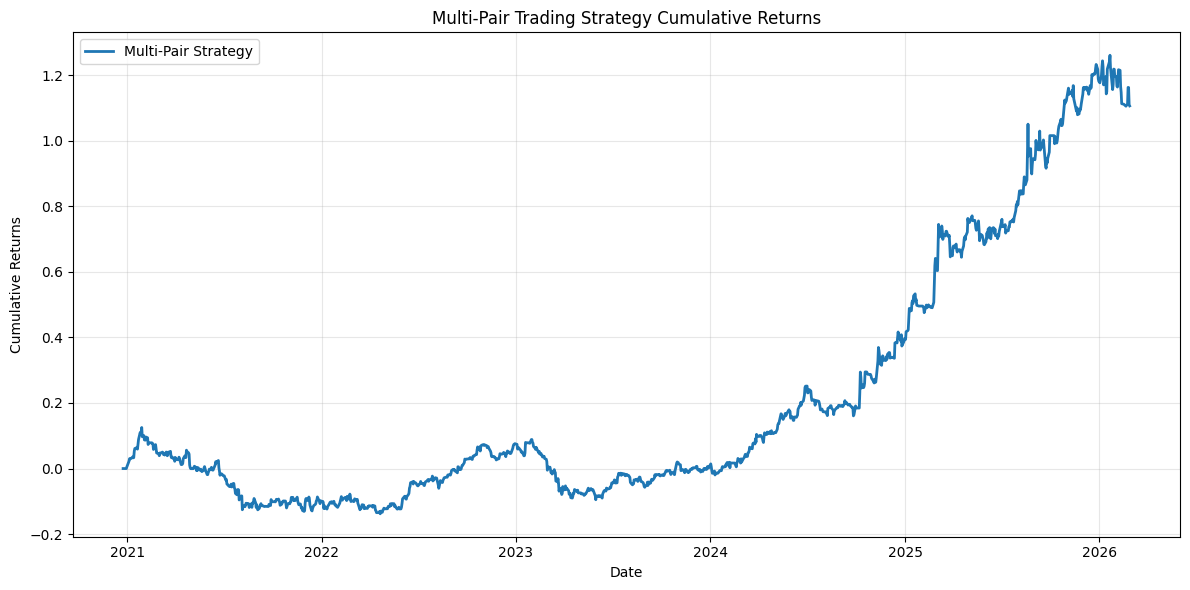

Sharpe Ratio (annualized): 0.8182


In [26]:
# Risk params: leverage and maintenance margin for margin call
leverage = 1
maintenance_margin_pct = 0.3
borrowing_pct_cost_annual = 0.068
short_sell_pct_cost_annual = 0.0112

stop_loss_pct = 0.01 * leverage ** 2

# Define initial capital
initial_capital = 100000 * len(pairs)

# Sharpe ratio parameters
risk_free_rate_annual = 0.03665
trades_log, daily_ex_returns, signals = backtest_strategy_multi_pair(
    z_scores=z_scores,
    price_data=price_data,
    tickers=tickers,
    stock_lots=tickers,  # dict mapping ticker to shares per lot
    pairs=pairs,
    windows=windows,
    leverage=leverage,
    maintenance_margin_pct=maintenance_margin_pct,
    borrowing_pct_cost_annual=borrowing_pct_cost_annual,
    short_sell_pct_cost_annual=short_sell_pct_cost_annual,
    entry_thresholds=entry_thresholds,
    exit_thresholds=exit_thresholds,
    stop_loss_pct=stop_loss_pct,
    initial_capital=initial_capital,
    risk_free_rate_annual=risk_free_rate_annual,
    plot_stock_return=True
)

In [27]:
# Save/print trade log
trades_df = pd.DataFrame(trades_log)
if not trades_df.empty:
    pass
    display(trades_df)
    # optional: save to CSV
    # trades_df.to_csv('trade_log.csv', index=False)

,pair,entry_index,entry_date,exit_index,exit_date,position,entry_capital,pnl,exit_cost,exit_reason
0,home electronics,5,2020-12-30,7,2021-01-04,-1,150000.000000,6859.642029,-132.408750,z_score
1,beer,7,2021-01-04,10,2021-01-07,1,153233.166850,2730.972290,-161.401785,z_score
2,semi-conductor,11,2021-01-08,12,2021-01-11,1,154351.645723,-2069.758545,-170.850575,stop_loss
3,home electronics,11,2021-01-08,12,2021-01-11,-1,154265.708135,3858.386993,-129.792591,z_score
4,home electronics,15,2021-01-14,17,2021-01-18,1,157402.224081,1699.555969,-122.761659,z_score
...,...,...,...,...,...,...,...,...,...,...
366,semi-conductor,1300,2026-02-10,1302,2026-02-12,-1,261970.355974,-8952.097321,-292.906497,stop_loss
367,home electronics,1301,2026-02-11,1305,2026-02-20,-1,257381.340650,-1143.994141,-272.482675,z_score
368,beer,1305,2026-02-20,1306,2026-02-23,-1,254039.985069,1970.996666,-278.612113,z_score
369,semi-conductor,1302,2026-02-12,1309,2026-02-26,-1,253073.989579,7402.443207,-280.086198,z_score


# Alpha Analysis

In [28]:
factor_df = pd.read_csv('F-F_Research_Data_Factors_daily.csv', skiprows=4, header=0)
mom_df = pd.read_csv('F-F_Momentum_Factor_daily.csv', skiprows=13, header=0)

# parse Date (files use YYYYMMDD) and coerce invalid/footer rows
factor_df['Date'] = pd.to_datetime(factor_df['Date'], format='%Y%m%d', errors='coerce')
mom_df['Date'] = pd.to_datetime(mom_df['Date'], format='%Y%m%d', errors='coerce')

# # drop rows with invalid dates (footers)
# factor_df = factor_df.dropna(subset=['Date']).copy()
# mom_df = mom_df.dropna(subset=['Date']).copy()

# remove any unnamed/footer columns from momentum file
mom_df = mom_df.loc[:, ~mom_df.columns.str.contains('^Unnamed')]

# merge, set Date as index and align to price_data index
carhart_df = pd.merge(factor_df, mom_df, on='Date', how='inner')
carhart_df = carhart_df.set_index('Date').sort_index()
carhart_df = carhart_df.loc[carhart_df.index.isin(price_data.index)]

# ensure numeric and convert from percent to decimal
carhart_df = carhart_df.apply(pd.to_numeric, errors='coerce') / 100
carhart_df = carhart_df[1:]
carhart_df

,Mkt-RF,SMB,HML,RF,Mom
Date,,,,,
2020-12-24,0.0023,-0.0040,-0.0019,0.0000,0.0021
2020-12-28,0.0049,-0.0073,0.0036,0.0000,-0.0048
2020-12-29,-0.0039,-0.0152,0.0024,0.0000,-0.0041
2020-12-30,0.0027,0.0101,0.0006,0.0000,-0.0025
2020-12-31,0.0040,-0.0086,0.0044,0.0000,-0.0058
...,...,...,...,...,...
2025-12-24,0.0029,0.0003,0.0001,0.0002,-0.0022
2025-12-26,-0.0006,-0.0032,0.0009,0.0002,-0.0020
2025-12-29,-0.0041,-0.0018,0.0007,0.0002,-0.0016


In [ ]:
# convert pct_returns (list) to a pandas Series with proper dates, then align with Carhart factors
strategy_returns = pd.Series(daily_ex_returns, index=price_data.index[1:1+len(daily_ex_returns)])

# align indices
common_idx = strategy_returns.index.intersection(carhart_df.index)

y = strategy_returns.loc[common_idx] - carhart_df.loc[common_idx, 'RF']
X = sm.add_constant(carhart_df.loc[common_idx, ['Mkt-RF', 'SMB', 'HML', 'Mom']])

reg = sm.OLS(y, X).fit()
print("annaulized alpha", (1+reg.params.iloc[0])**252-1)
print(reg.summary())

annaulized alpha 0.09898647846811004
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.3624
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.835
Time:                        14:40:15   Log-Likelihood:                 4050.1
No. Observations:                1227   AIC:                            -8090.
Df Residuals:                    1222   BIC:                            -8065.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          